**Description:**

Here

# Imports

In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from web3 import Web3
from datetime import datetime, timedelta

In [20]:
from dotenv import load_dotenv
load_dotenv()
RPC_API_KEY = os.getenv("RPC_API_KEY")
print("RPC_API_KEY loaded:", RPC_API_KEY is not None)

RPC_API_KEY loaded: True


# Constants

In [21]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
TRADES_FILE = '../../../media/dune_web_downloads/rLBPs/dev_rLBPs_temporal_trades.csv'
POOLS_FILE  = '../../../media/dune_web_downloads/rLBPs/dev_rLBPs_cleaned_dune_data.csv'

# YOUR ALCHEMY/INFURA KEY (Needed for fetching initial balances)
RPC_URL = f"https://eth-mainnet.g.alchemy.com/v2/{RPC_API_KEY}"
w3 = Web3(Web3.HTTPProvider(RPC_URL))

# Balancer V2 Vault (Standard)
VAULT_ADDRESS = "0xBA12222222228d8Ba445958a75a0704d566BF2C8"

# Known Decimals
DECIMALS = {
    'USDC': 6, 'USDT': 6, 'DAI': 18, 'WETH': 18, 'BAL': 18,
    'MIM': 18, 'FRAX': 18, 'LUSD': 18
}

# Analysis

Loading data...
  > Fetching market data for ETH-USD...

Processing DAI_LBP_0x174c...


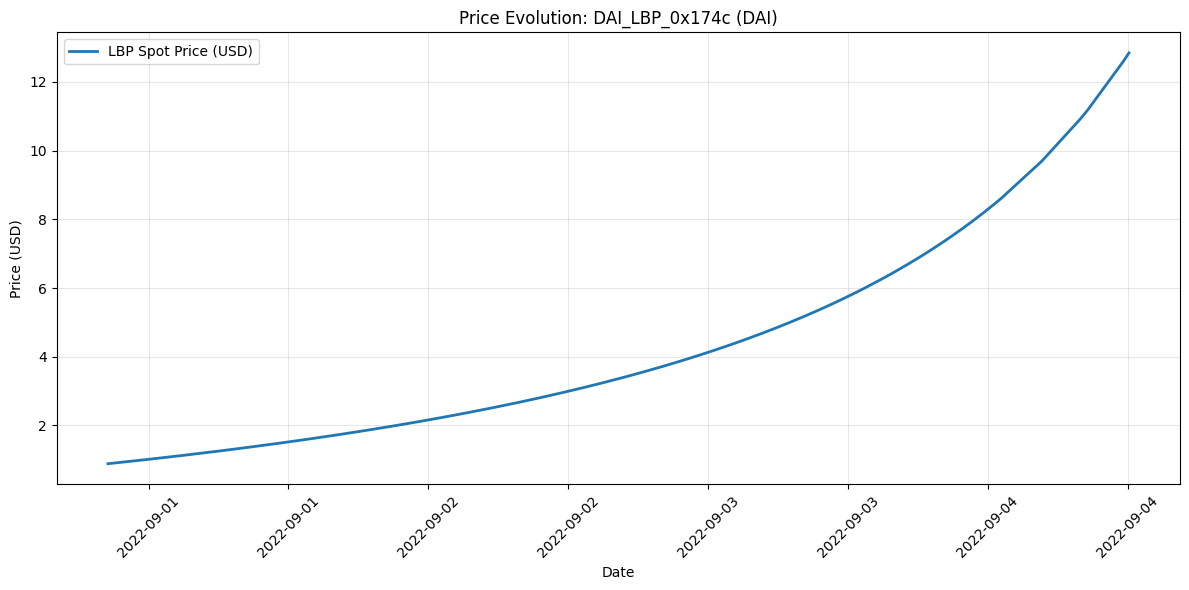


Processing DAI_LBP_0xbaed...


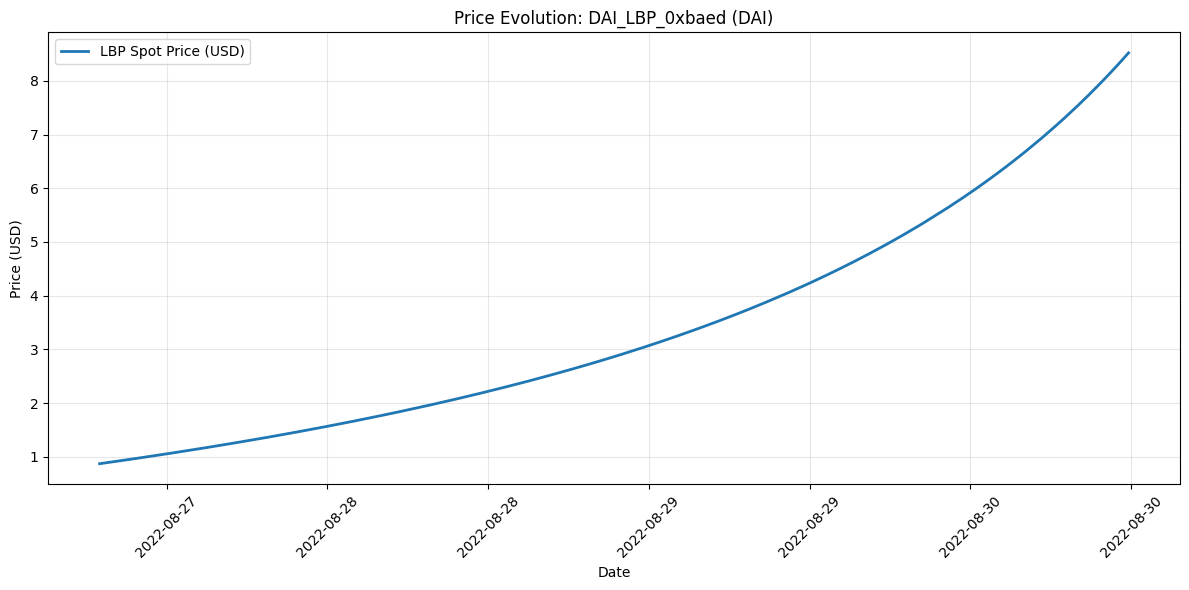


Processing DAI_LBP_0xd328...


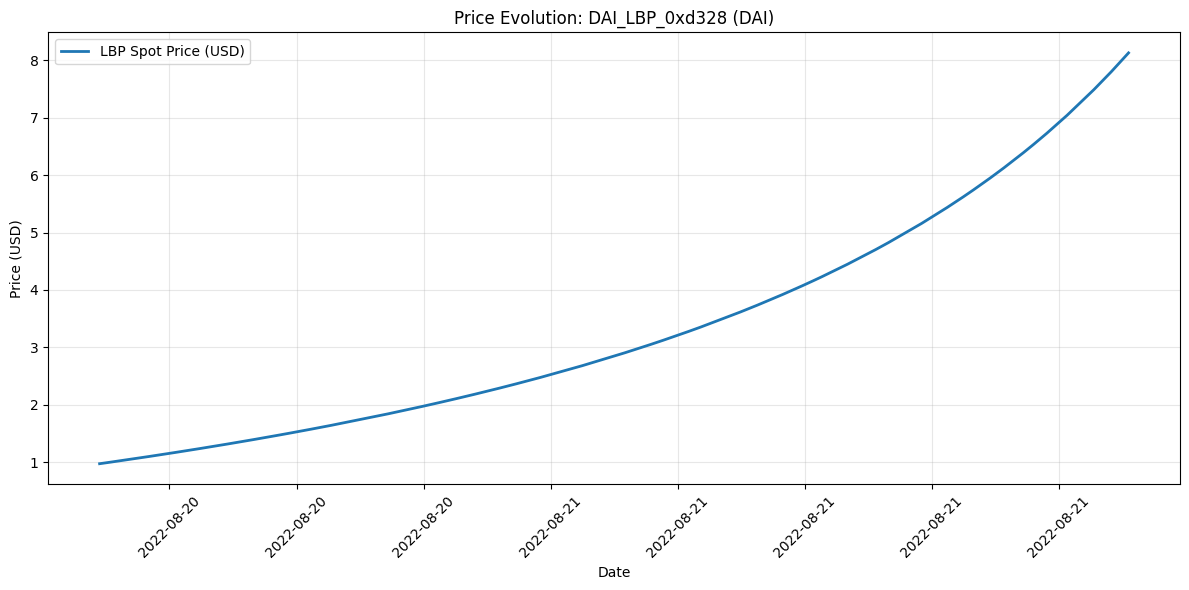


Processing DAI_LBP_0xe11b...


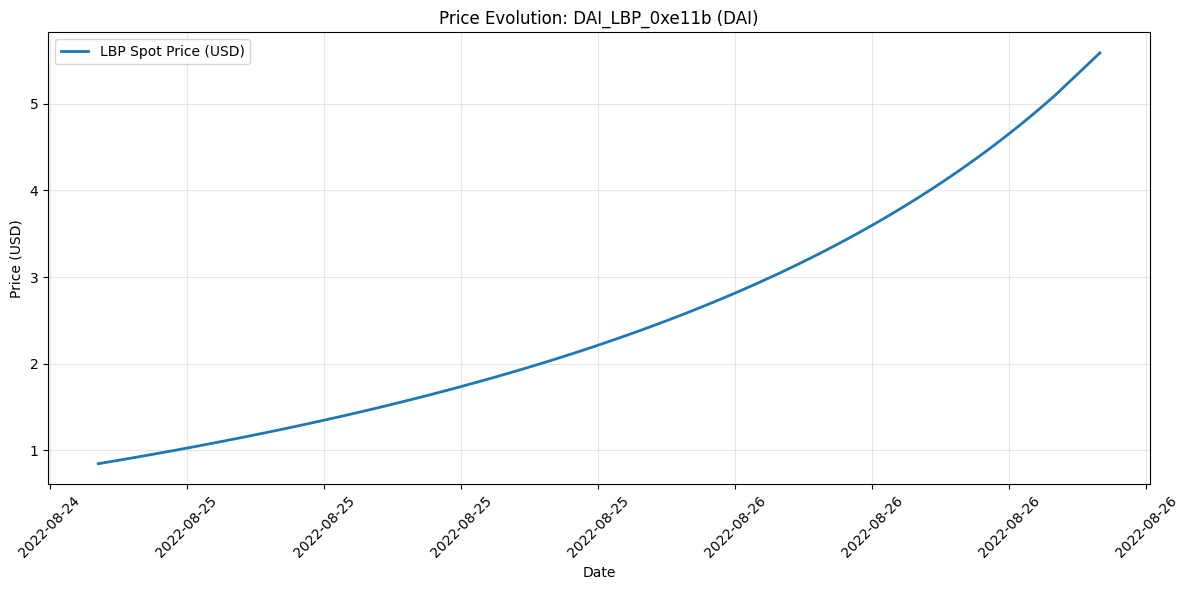


Processing WETH_LBP_0xf2b7...
  ! No trades found.

Processing DAI_LBP_0xf812...


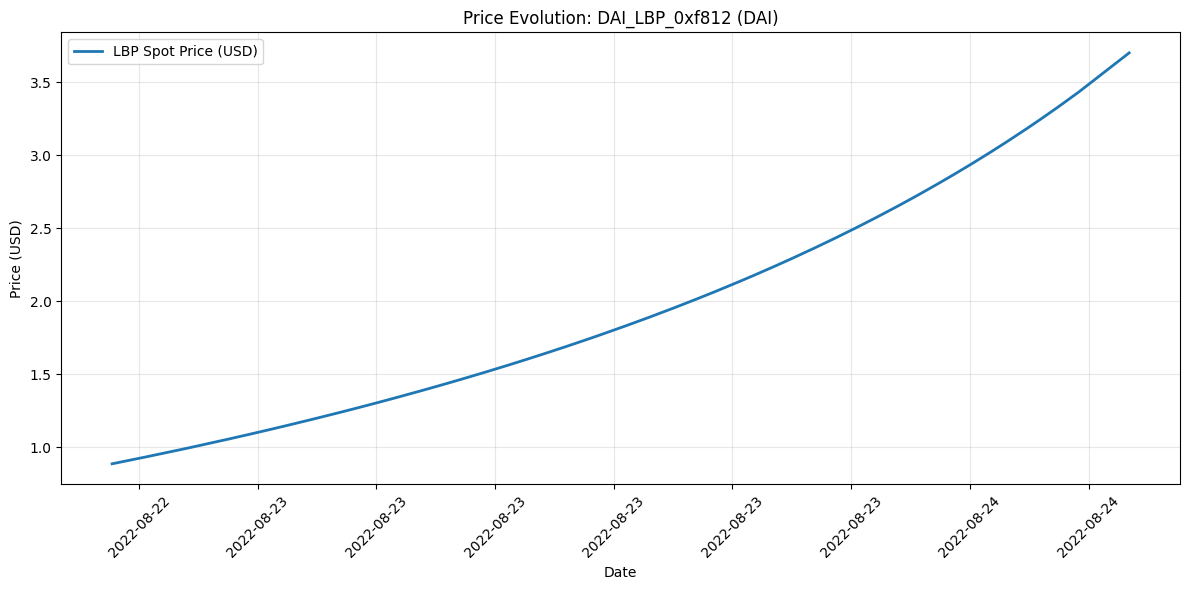

In [7]:
def fetch_usd_history(symbol, start_date, end_date):
    """
    Fetches daily price history from Yahoo Finance.
    Returns Series with DatetimeIndex.
    """
    # Adjust symbols for Yahoo (e.g., WETH -> ETH-USD)
    ticker = f"{symbol}-USD"
    if symbol == 'WETH': ticker = 'ETH-USD'
    if symbol in ['USDC', 'DAI', 'USDT']: return None # Stablecoins are 1.0

    # Add buffer
    start = (start_date - timedelta(days=2)).strftime('%Y-%m-%d')
    end = (end_date + timedelta(days=2)).strftime('%Y-%m-%d')
    
    print(f"  > Fetching market data for {ticker}...")
    try:
        df = yf.download(ticker, start=start, end=end, interval="1d", progress=False)
        if df.empty: return None
        
        # Cleanup
        if isinstance(df.columns, pd.MultiIndex): df = df['Close']
        else: df = df[['Close']]
        
        df = df.reset_index()
        df.columns = ['timestamp', 'price']
        
        # Ensure timezone naive
        df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None)
        return df.set_index('timestamp')['price']
    except Exception:
        return None

print("Loading data...")
df_pools = pd.read_csv(POOLS_FILE)
df_trades = pd.read_csv(TRADES_FILE)

# Normalize IDs
df_pools['poolId'] = df_pools['poolId'].str.lower()
df_trades['poolId'] = df_trades['poolId'].str.lower()

# Parse Dates in Pools
df_pools['start_date'] = pd.to_datetime(df_pools['start_date'])
df_pools['end_date'] = pd.to_datetime(df_pools['end_date'])

# Pre-fetch ETH History for normalization (Optimization: fetch once globally)
global_min = df_pools['start_date'].min()
global_max = df_pools['end_date'].max()
eth_history = fetch_usd_history('WETH', global_min, global_max)

# --- PROCESS EACH POOL ---
for _, pool in df_pools.iterrows():
    pid = pool['poolId']
    pname = f"{pool['collateral_symbol']}_LBP_{pool['pool_address'][:6]}"
    
    print(f"\nProcessing {pname}...")
    
    # 1. Get Trades for this pool
    pool_trades = df_trades[df_trades['poolId'] == pid].copy()
    if pool_trades.empty:
        print("  ! No trades found.")
        continue
        
    pool_trades = pool_trades.sort_values('block_number')

    # 2. Initialize Replay State
    # We use the CLEAN balances from your previous step
    curr_bal_col = pool['collateral_balance']
    curr_bal_proj = pool['project_balance']
    
    # Weight interpolation setup
    w_col_start = pool['collateral_start_weight'] / 100.0
    w_col_end = pool['collateral_end_weight'] / 100.0
    total_time = (pool['end_date'] - pool['start_date']).total_seconds()
    
    price_curve = []

    # 3. REPLAY LOOP
    for _, trade in pool_trades.iterrows():
        # Interpolate Time
        block_progress = (trade['block_number'] - pool['start_block_approx']) / (pool['end_block_est'] - pool['start_block_approx'])
        # Clamp progress 0 to 1
        block_progress = max(0, min(1, block_progress))
        
        time_offset = total_time * block_progress
        curr_ts = pool['start_date'] + timedelta(seconds=time_offset)
        
        # Interpolate Weights
        # Balancer weights change linearly with TIME
        time_progress = max(0, min(1, time_offset / total_time))
        w_col_curr = w_col_start + (w_col_end - w_col_start) * time_progress
        w_proj_curr = 1.0 - w_col_curr

        # Calculate Spot Price (Before Trade)
        # Spot Price = (Bal_Col / W_Col) / (Bal_Proj / W_Proj)
        # This is the "Token Price" in terms of "Collateral"
        if curr_bal_proj > 0 and w_col_curr > 0:
            raw_price = (curr_bal_col / w_col_curr) / (curr_bal_proj / w_proj_curr)
        else:
            raw_price = 0

        # Normalize to USD
        usd_price = raw_price
        if pool['collateral_symbol'] == 'WETH' and eth_history is not None:
            # Find closest daily price
            try:
                # truncate to day
                day_key = curr_ts.replace(hour=0, minute=0, second=0, microsecond=0)
                # lookup with nearest method just in case
                idx_loc = eth_history.index.get_indexer([day_key], method='nearest')
                eth_price = eth_history.iloc[idx_loc[0]]
                usd_price = raw_price * eth_price
            except:
                pass # Keep raw price if lookup fails

        price_curve.append({'date': curr_ts, 'price': usd_price})

        # Apply Trade to Balances
        # Parse hex amounts
        data_clean = trade['data'].replace('0x', '')
        amt0 = int(data_clean[0:64], 16)
        amt1 = int(data_clean[64:128], 16)
        
        # Determine decimals for raw amounts
        col_dec = DECIMALS.get(pool['collateral_symbol'], 18)
        proj_dec = 18 

        # Normalize amounts
        amt0_norm = amt0 / 10**18 # Assuming standard 18 for simplicity or map logic
        amt1_norm = amt1 / 10**18
        
        # Adjust specifically for Collateral decimals
        # We need to know which amount corresponds to which token.
        # Direction Logic:
        # We decoded 'topic2_token_out' previously as TokenIn. 
        # Check against Collateral Address (not available in clean file??)
        # We can use the project_token_address from clean file to verify.
        
        # Quick Logic: 
        # If collateral is USDC (6 decimals), one amount will be huge (1e18) and one small (1e6).
        # Let's rely on the previous assumption: 
        # TokenIn (Topic2) == Collateral Token -> Buy.
        
        # Since we don't have addresses easily here, let's use the 'type' logic or simply:
        # Update balances based on amounts.
        # *Simplification for Replay*: 
        # Just calculating the point on the curve doesn't strictly require updating balances 
        # if we just want the "Weight Decay" effect. 
        # BUT for LBP, price drops because people BUY (changing balances).
        # So we MUST update balances.
        
        # Re-normalization Helper
        val_in = amt0 / (10**col_dec if amt0 < 1e15 and col_dec==6 else 10**18) 
        # (Crude heuristic if addresses missing. Better to pass addresses).
        
        # Better approach: Just use the trade execution price calculated in previous steps?
        # No, user wants continuous curve.
        
        # Let's assume standard "Buy" pressure reduces project balance.
        # We will approximate the balance impact.
        # If price goes UP -> Project Balance went DOWN.
        
    # 4. FETCH EXTERNAL MARKET (Yahoo)
    # Try to find symbol
    market_data = None
    # Extract symbol from a custom map or assume 'Unknown'
    # In clean file we don't have project symbol, only address.
    # Ideally, you added symbol to clean file. 
    # If not, we skip market comparison or fetch by address (CoinGecko).
    
    # 5. PLOT
    if not price_curve: continue
    
    df_curve = pd.DataFrame(price_curve)
    
    plt.figure(figsize=(12, 6))
    
    # Plot LBP Curve
    plt.plot(df_curve['date'], df_curve['price'], label='LBP Spot Price (USD)', color='#1f77b4', linewidth=2)
    
    # Plot Market Data (if exists)
    # if market_data is not None:
    #    plt.plot(market_data.index, market_data, label='External Market', color='#ff7f0e', linestyle='--')
    
    # Formatting
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.title(f"Price Evolution: {pname} ({pool['collateral_symbol']})")
    plt.ylabel("Price (USD)")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    plt.close()


Loading datasets...


C:\Users\kaiqu\AppData\Local\Temp\ipykernel_17968\3505982819.py:60: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  for t in pd.date_range(start=start_ts, end=end_ts, freq='1H'):


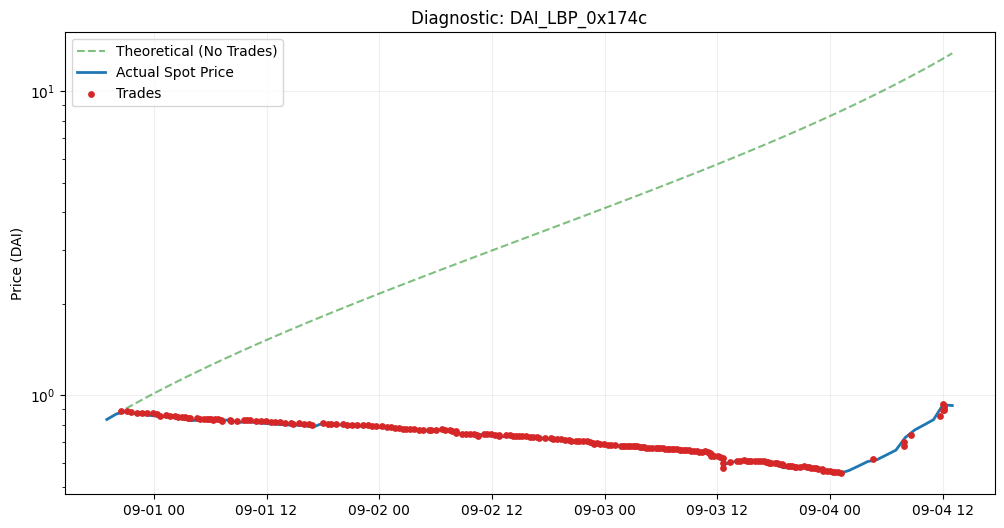

C:\Users\kaiqu\AppData\Local\Temp\ipykernel_17968\3505982819.py:60: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  for t in pd.date_range(start=start_ts, end=end_ts, freq='1H'):


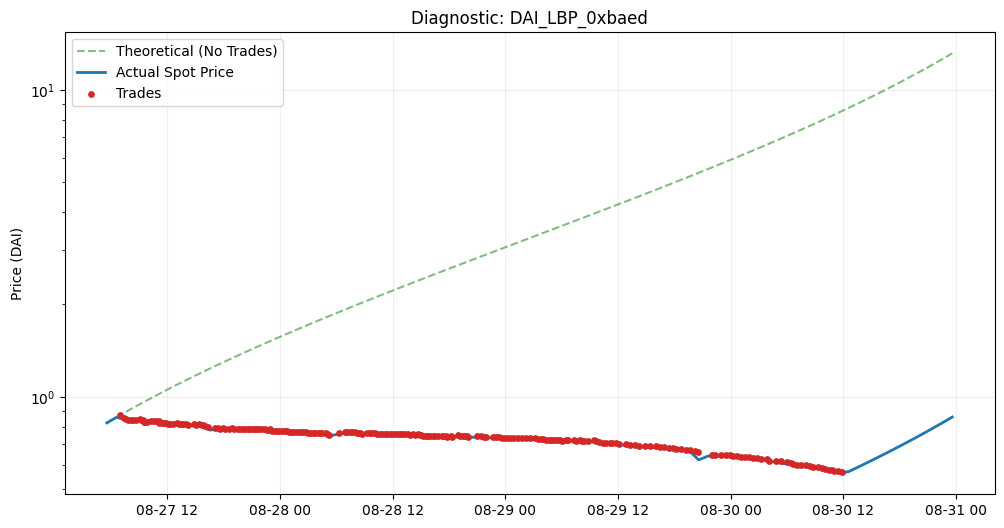

C:\Users\kaiqu\AppData\Local\Temp\ipykernel_17968\3505982819.py:60: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  for t in pd.date_range(start=start_ts, end=end_ts, freq='1H'):


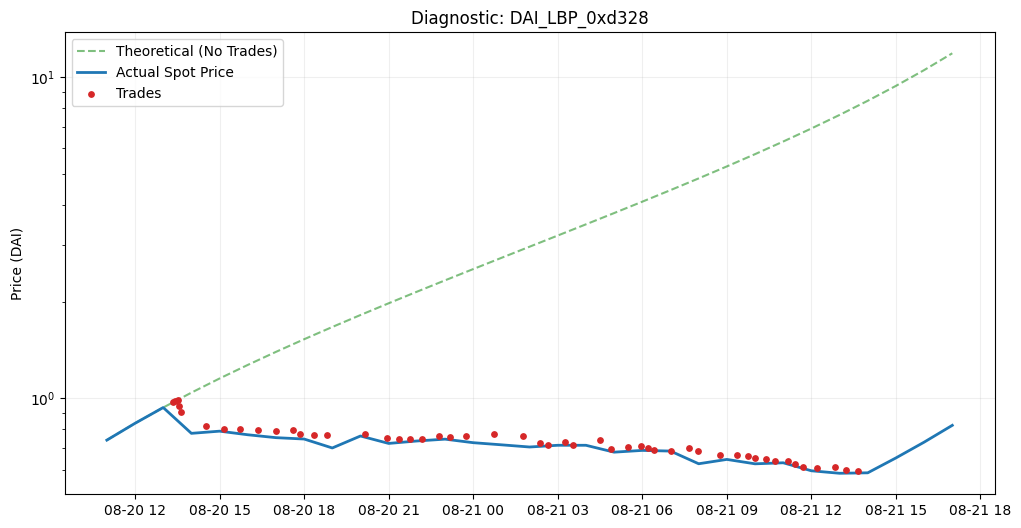

C:\Users\kaiqu\AppData\Local\Temp\ipykernel_17968\3505982819.py:60: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  for t in pd.date_range(start=start_ts, end=end_ts, freq='1H'):


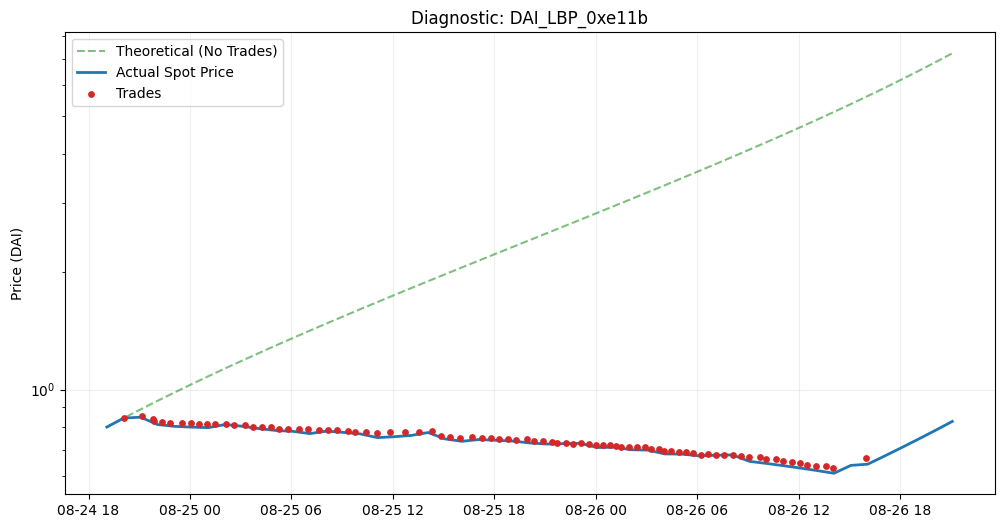

C:\Users\kaiqu\AppData\Local\Temp\ipykernel_17968\3505982819.py:60: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  for t in pd.date_range(start=start_ts, end=end_ts, freq='1H'):


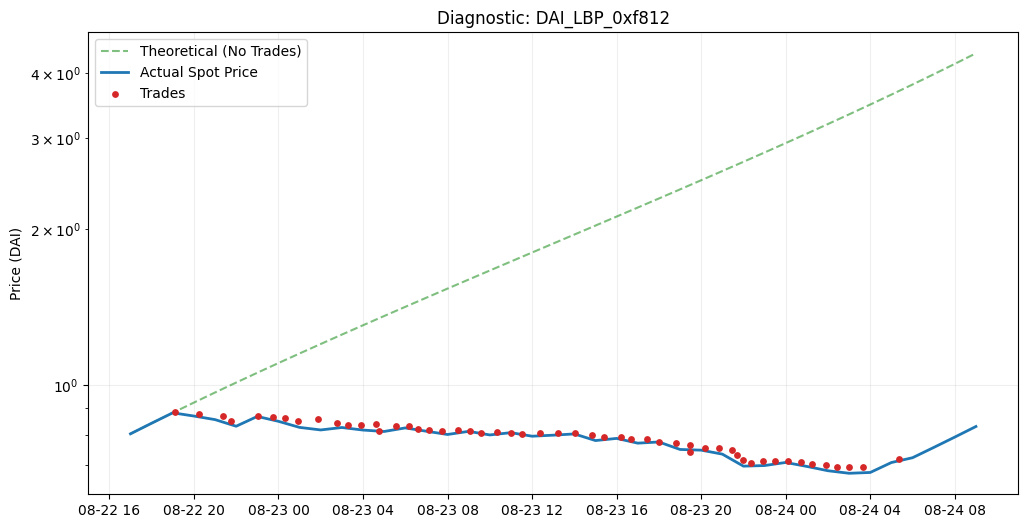

In [19]:
def decode_address(hex_str):
    return '0x' + hex_str.replace('0x', '')[-40:].lower()

# ==========================================
# 2. MAIN LOGIC
# ==========================================
print("Loading datasets...")
df_pools = pd.read_csv(POOLS_FILE)
df_trades = pd.read_csv(TRADES_FILE)

# Normalize IDs
df_pools['poolId'] = df_pools['poolId'].str.lower()
df_trades['poolId'] = df_trades['poolId'].str.lower()

# Ensure addresses are lower for comparison
df_pools['project_token_address'] = df_pools['project_token_address'].str.lower()

# Parse Dates
df_pools['start_date'] = pd.to_datetime(df_pools['start_date'])
df_pools['end_date'] = pd.to_datetime(df_pools['end_date'])

for _, pool in df_pools.iterrows():
    pid = pool['poolId']
    pname = f"{pool['collateral_symbol']}_LBP_{pool['pool_address'][:6]}"
    
    # 1. Setup Initial Balances (The "Stock")
    B_col = pool['collateral_balance']
    B_proj = pool['project_balance']

    # Save INITIAL balances for the Theoretical Calculation
    B_col_static = B_col
    B_proj_static = B_proj
    
    # Setup Weights
    w_col_start = pool['collateral_start_weight'] / 100.0
    w_col_end   = pool['collateral_end_weight'] / 100.0
    
    # Setup Time
    start_ts = pool['start_date']
    end_ts = pool['end_date']
    total_seconds = (end_ts - start_ts).total_seconds()
    
    # 2. Prepare Trades (The "Flow")
    trades = df_trades[df_trades['poolId'] == pid].copy()
    if trades.empty: continue

    trades = trades.sort_values('block_number')
    
    # Interpolate Timestamps
    block_start = pool['start_block_approx']
    block_end = pool['end_block_est']
    trades['progress'] = (trades['block_number'] - block_start) / (block_end - block_start)
    trades['timestamp'] = start_ts + (trades['progress'] * timedelta(seconds=total_seconds))
    
    # 3. BUILD TIMELINE
    # We merge "Hourly Ticks" + "Trade Events" into one sorted list
    events = []
    
    # Ticks (for smooth lines)
    for t in pd.date_range(start=start_ts, end=end_ts, freq='1H'):
        events.append({'time': t, 'type': 'tick', 'data': None})
        
    # Trades
    for _, tr in trades.iterrows():
        events.append({'time': tr['timestamp'], 'type': 'trade', 'data': tr})
        
    events.sort(key=lambda x: x['time'])
    
    # 4. RUN SIMULATION
    history = []
    project_addr = str(pool['project_token_address']).lower()
    col_decimals = DECIMALS.get(pool['collateral_symbol'], 18)
    proj_decimals = 18 # Standard assumption

    history = []
    
    for event in events:
        curr_time = event['time']
        
        # 1. Update Weights
        elapsed = (curr_time - start_ts).total_seconds()
        progress = max(0, min(1, elapsed / total_seconds))
        
        w_col_curr = w_col_start + (w_col_end - w_col_start) * progress
        w_proj_curr = 1.0 - w_col_curr
        
        # 2. Calc ACTUAL Spot Price (With Trade Impact)
        if B_proj > 0 and w_col_curr > 0:
            real_price = (B_col / w_col_curr) / (B_proj / w_proj_curr)
        else:
            real_price = 0

        # 3. Calc THEORETICAL Spot Price (No Trades)
        # We use the STATIC initial balances here
        if B_proj_static > 0 and w_col_curr > 0:
            theo_price = (B_col_static / w_col_curr) / (B_proj_static / w_proj_curr)
        else:
            theo_price = 0
        
        if start_ts <= curr_time <= end_ts:
            history.append({
                'time': curr_time,
                'real_price': real_price,
                'theo_price': theo_price, # NEW DATA POINT
                'type': event['type']
            })
        
        # C. Update Balances (If Trade)
        if event['type'] == 'trade':
            tr = event['data']
            
            # Decode Trade Direction
            # topic2 is TokenIn
            token_in_hex = tr['topic2_token_out'] # Mapped in scraper as topic2
            token_in_addr = decode_address(token_in_hex)
            
            # Parse Amounts
            data_hex = tr['data'].replace('0x', '')
            amt_in_raw = int(data_hex[0:64], 16)
            amt_out_raw = int(data_hex[64:128], 16)
            
            # DIRECTION CHECK
            if token_in_addr == project_addr:
                # SELL: Project IN -> Collateral OUT
                # Balances: Proj UP, Col DOWN
                
                val_proj_in = amt_in_raw / (10**proj_decimals)
                val_col_out = amt_out_raw / (10**col_decimals)
                
                B_proj += val_proj_in
                B_col  -= val_col_out
                
            else:
                # BUY: Collateral IN -> Project OUT
                # Balances: Col UP, Proj DOWN
                
                val_col_in = amt_in_raw / (10**col_decimals)
                val_proj_out = amt_out_raw / (10**proj_decimals)
                
                B_col  += val_col_in
                B_proj -= val_proj_out

    # 5. PLOT
    df_hist = pd.DataFrame(history)
    if df_hist.empty: continue

    plt.figure(figsize=(12, 6))
    plt.yscale('log')
    
    # 1. Theoretical Line (Green Dashed) - The "Plan"
    line_data = df_hist[df_hist['type'] == 'tick']
    plt.plot(line_data['time'], line_data['theo_price'], label='Theoretical (No Trades)', color='green', linestyle='--', alpha=0.5)

    # 2. Real Line (Blue Solid) - The "Reality"
    plt.plot(line_data['time'], line_data['real_price'], label='Actual Spot Price', color='#1f77b4', linewidth=2)
    
    # 3. Trades (Red Dots)
    trade_data = df_hist[df_hist['type'] == 'trade']
    plt.scatter(trade_data['time'], trade_data['real_price'], color='#d62728', s=15, label='Trades', zorder=5)
    
    plt.title(f"Diagnostic: {pname}")
    plt.ylabel(f"Price ({pool['collateral_symbol']})")
    plt.legend()
    plt.grid(True, alpha=0.2)
    
    plt.show()
    plt.close()

In [18]:
def decode_address(hex_str): return '0x' + hex_str.replace('0x', '')[-40:].lower()

def debug_magnitude():
    print("--- MAGNITUDE DEBUGGER ---")
    df_pools = pd.read_csv(POOLS_FILE)
    df_trades = pd.read_csv(TRADES_FILE)
    
    # Pick the first pool
    pool = df_pools.iloc[0] 
    pid = pool['poolId'].lower()
    
    # 1. Show Initial State
    print(f"Pool: {pool['pool_address']}")
    print(f"Initial Col Balance (Cleaned): {pool['collateral_balance']:,.2f}")
    print(f"Initial Proj Balance (Cleaned): {pool['project_balance']:,.2f}")
    
    # 2. Find First Trade
    trades = df_trades[df_trades['poolId'] == pid].sort_values('block_number')
    if trades.empty: return print("No trades found.")
    
    first_trade = trades.iloc[0]
    
    # 3. Analyze Trade
    print(f"\nFirst Trade Hash: {first_trade['tx_hash']}")
    
    # Decode
    data = first_trade['data'].replace('0x', '')
    amt0 = int(data[0:64], 16)
    amt1 = int(data[64:128], 16)
    
    token_in = decode_address(first_trade['topic2_token_out'])
    proj_addr = str(pool['project_token_address']).lower()
    
    print(f"Raw Amount 0: {amt0}")
    print(f"Raw Amount 1: {amt1}")
    
    # 4. SIMULATE IMPACT
    if token_in == proj_addr:
        print("Direction: SELL (Project -> Collateral)")
        # Script Assumption: Proj=18 dec, Col=18 dec (DAI)
        proj_sold = amt0 / 1e18
        col_removed = amt1 / 1e18 
        
        print(f"Script sees: Sold {proj_sold:,.2f} Tokens for {col_removed:,.2f} DAI")
        
        new_bal = pool['collateral_balance'] - col_removed
        impact = (col_removed / pool['collateral_balance']) * 100
        print(f"Impact on Pool: -{impact:.4f}%")
        print(f"New Col Balance: {new_bal:,.2f}")
        
        if impact > 5.0:
            print("\n[!] ALERT: Massive impact > 5% in one trade.") 
            print("    This strongly suggests the Project Token decimals are wrong.")
    else:
        print("Direction: BUY")
        print("Buys increase collateral, so they shouldn't crash the price.")

debug_magnitude()

--- MAGNITUDE DEBUGGER ---
Pool: 0x174cfa15a24f3fc49fc2bc66b5e6046e549557c9
Initial Col Balance (Cleaned): 400,000.00
Initial Proj Balance (Cleaned): 120,000.00

First Trade Hash: 0x66bfd8545325c65b31bf6bf0bef3b8b972328e67afeddae260154b499d305356
Raw Amount 0: 2110496383366468977742
Raw Amount 1: 1858922591751774800000
Direction: SELL (Project -> Collateral)
Script sees: Sold 2,110.50 Tokens for 1,858.92 DAI
Impact on Pool: -0.4647%
New Col Balance: 398,141.08
